Generating sweep...
>  0 Teensy MIDI_Audio, Core Audio (2 in, 0 out)
<  1 Teensy MIDI_Audio, Core Audio (0 in, 2 out)
   2 MacBook Pro Microphone, Core Audio (1 in, 0 out)
   3 MacBook Pro Speakers, Core Audio (0 in, 2 out)
   4 Microsoft Teams Audio, Core Audio (1 in, 1 out)
   5 ZoomAudioDevice, Core Audio (2 in, 2 out)
   6 Teensy & HP, Core Audio (0 in, 0 out)
   7 Aggregate Device, Core Audio (0 in, 0 out)
   8 Teensy and Speakers, Core Audio (0 in, 2 out)
   9 teensy io combined, Core Audio (0 in, 0 out)
  10 HaptiCoupler n Speakers, Core Audio (2 in, 4 out)
Playing and recording...
Done recording.
Estimated Wideband Gain: -1.56 dB
`ftol` termination condition is satisfied.
Function evaluations 39, initial cost 5.7406e+05, final cost 2.4247e+03, first-order optimality 1.42e+00.

Fitted cascade biquad coefficients (overall, a0 normalized to 1):
b_total = [ 0.16288198 -0.53268812  0.63043386 -0.3143011   0.05367515]
a_total = [ 1.         -3.79912212  5.40915938 -3.42077049  0.8107

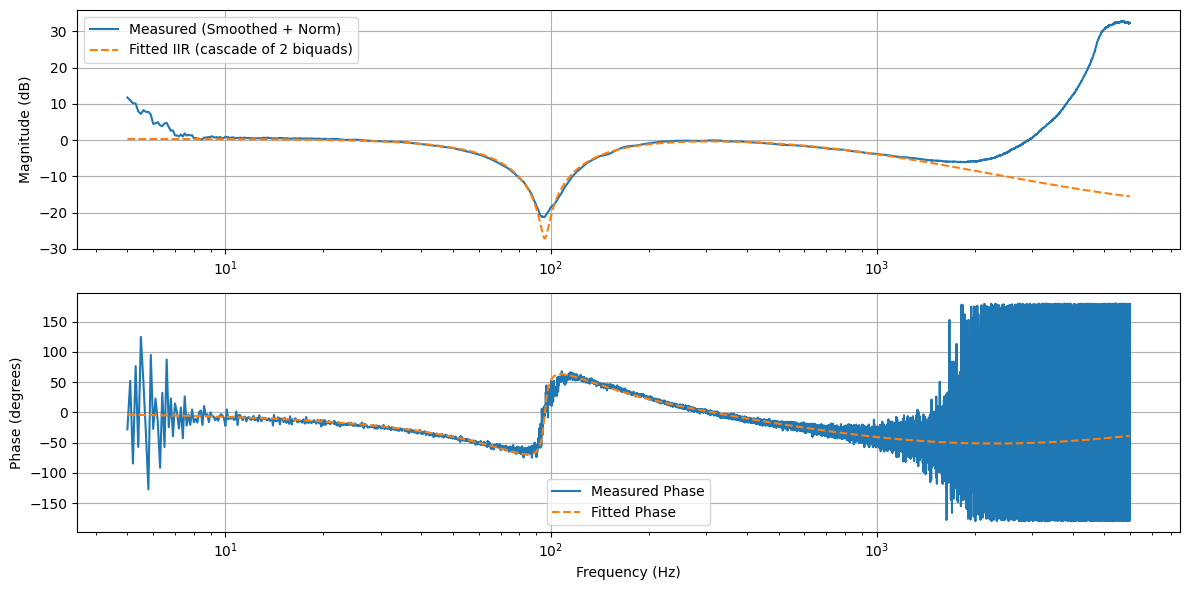

In [1]:
import numpy as np
import sounddevice as sd
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

def generate_sweep(fs, duration, f_start, f_end):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    sweep = signal.chirp(t, f0=f_start, f1=f_end, t1=duration, method='logarithmic')
    return t, sweep

def measure_system_response(fs, duration, f_start, f_end, input_gain=0.1):
    print("Generating sweep...")
    t, sweep = generate_sweep(fs, duration, f_start, f_end)
    sweep = sweep * input_gain

    print(sd.query_devices())

    print("Playing and recording...")
    recording = sd.playrec(sweep, samplerate=fs, channels=2, dtype='float64')
    sd.wait()
    print("Done recording.")

    return recording[:, 1], recording[:, 0]

def smooth_magnitude(freqs, magnitude, smoothing_octaves=0.1):
    smoothed = np.zeros_like(magnitude)
    for i, f in enumerate(freqs):
        if f <= 0:
            smoothed[i] = magnitude[i]
            continue
        f_low = f * 2**(-smoothing_octaves / 2)
        f_high = f * 2**(smoothing_octaves / 2)
        mask = (freqs >= f_low) & (freqs <= f_high)
        if np.any(mask):
            smoothed[i] = np.mean(magnitude[mask])
        else:
            smoothed[i] = magnitude[i]
    return smoothed

def compute_transfer_function_fft(input_signal, output_signal, fs):
    N = len(input_signal)
    window = np.hanning(N)
    input_windowed = input_signal * window
    output_windowed = output_signal * window

    X = np.fft.rfft(input_windowed)
    Y = np.fft.rfft(output_windowed)
    freqs = np.fft.rfftfreq(N, d=1/fs)

    X = np.where(np.abs(X) < 1e-12, 1e-12, X)
    H = Y / X
    return freqs, H

def iir_filter_response(b, a, freqs, fs):
    w = 2 * np.pi * freqs / fs
    _, h = signal.freqz(b, a, worN=w)
    return h

def peaking_eq_biquad(f0, Q, gain_db, fs):
    """
    Standard RBJ peaking EQ biquad.

    Returns (b, a) with a0 normalized to 1.0.
    """
    A = 10**(gain_db / 40)
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)

    b0 =   1 + alpha * A
    b1 =  -2 * np.cos(w0)
    b2 =   1 - alpha * A
    a0 =   1 + alpha / A
    a1 =  -2 * np.cos(w0)
    a2 =   1 - alpha / A

    # normalize
    b = np.array([b0, b1, b2]) / a0
    a = np.array([1.0, a1 / a0, a2 / a0])
    return b, a

# ---------------- New fitting code: fit two cascaded biquads ----------------

def biquad_response_from_params_single(params, w):
    """
    Single biquad from params = [b0, b1, b2, p_r, p_theta]
    returns H(w) for that biquad
    """
    b0, b1, b2, p_r, p_theta = params
    r = np.clip(p_r, 0.0, 0.9999)
    theta = np.clip(p_theta, 0.0, np.pi)
    a1 = -2.0 * r * np.cos(theta)
    a2 = r**2

    jw = np.exp(-1j * w)
    num = b0 + b1 * jw + b2 * (jw**2)
    den = 1.0 + a1 * jw + a2 * (jw**2)
    H = num / den
    return H

def biquads_series_response_from_params(params, w):
    """
    params: length 10
      [b0_1,b1_1,b2_1,r1,th1, b0_2,b1_2,b2_2,r2,th2]
    returns H_total = H1 * H2 over w
    """
    p1 = params[0:5]
    p2 = params[5:10]
    H1 = biquad_response_from_params_single(p1, w)
    H2 = biquad_response_from_params_single(p2, w)
    return H1 * H2

def residuals_two_biquads(params, w, H_target, mag_only=False):
    """
    Residuals between series biquads response and target.
    If mag_only True, compare magnitudes only.
    Else compare complex (real + imag stacked).
    """
    H_est = biquads_series_response_from_params(params, w)
    if mag_only:
        return np.abs(H_est) - np.abs(H_target)
    else:
        return np.concatenate([np.real(H_est - H_target), np.imag(H_est - H_target)])

def fit_two_biquads_in_series(freqs, H_target, fs, fit_freq_range=None, mag_only=False):
    """
    Fit two biquads in series by optimizing both sections' parameters:
    each section parameterized by numerator (b0,b1,b2) and pole (r,theta).
    Returns:
      b_total, a_total (convolved polynomials), individual params, optimizer result
    """
    if fit_freq_range is not None:
        fmin, fmax = fit_freq_range
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_fit = freqs[mask]
        H_fit = H_target[mask]
    else:
        freqs_fit = freqs
        H_fit = H_target

    w = 2.0 * np.pi * freqs_fit / fs

    # ------------------------------------------------------------
    # Initial guess #1: first biquad = peaking EQ @ 100 Hz, Q=4, -20 dB
    # Initial guess #2: second biquad = flat numerator, mild poles (r=0.8, theta=pi/8)
    # ------------------------------------------------------------
    f0_init = 100.0
    Q_init = 4.0
    gain_init_db = -20.0
    b1_init, a1_init = peaking_eq_biquad(f0_init, Q_init, gain_init_db, fs)
    # extract pole radius/angle from a1_init
    a1_a1 = a1_init[1]
    a1_a2 = a1_init[2]
    poles1 = np.roots([1.0, a1_a1, a1_a2])
    p1 = poles1[0]
    r1_init = np.clip(np.abs(p1), 0.0, 0.9999)
    theta1_init = np.mod(np.angle(p1), np.pi)

    # second biquad initial guess: flat numerator
    b2_init = np.array([1.0, 0.0, 0.0])
    r2_init = 0.8
    theta2_init = np.pi / 8.0

    # build combined initial parameter vector length 10
    x0 = np.hstack([b1_init[0], b1_init[1], b1_init[2], r1_init, theta1_init,
                    b2_init[0], b2_init[1], b2_init[2], r2_init, theta2_init])

    # bounds for optimizer
    lower = [-np.inf, -np.inf, -np.inf, 0.0, 0.0,
             -np.inf, -np.inf, -np.inf, 0.0, 0.0]
    upper = [ np.inf,  np.inf,  np.inf, 0.9999, np.pi,
              np.inf,  np.inf,  np.inf, 0.9999, np.pi]

    # run optimizer
    result = least_squares(
        residuals_two_biquads,
        x0,
        args=(w, H_fit, mag_only),
        bounds=(lower, upper),
        method='trf',
        max_nfev=4000,
        verbose=1
    )

    # unpack optimized params
    p_opt = result.x
    b0_1, b1_1, b2_1, pr1, th1, b0_2, b1_2, b2_2, pr2, th2 = p_opt

    # compute a coefficients for each section and ensure stability via clipping
    r1 = np.clip(pr1, 0.0, 0.9999)
    theta1 = np.clip(th1, 0.0, np.pi)
    a1_section_a1 = -2.0 * r1 * np.cos(theta1)
    a1_section_a2 = r1**2

    r2 = np.clip(pr2, 0.0, 0.9999)
    theta2 = np.clip(th2, 0.0, np.pi)
    a2_section_a1 = -2.0 * r2 * np.cos(theta2)
    a2_section_a2 = r2**2

    b_section_1 = np.array([b0_1, b1_1, b2_1])
    a_section_1 = np.array([1.0, a1_section_a1, a1_section_a2])

    b_section_2 = np.array([b0_2, b1_2, b2_2])
    a_section_2 = np.array([1.0, a2_section_a1, a2_section_a2])

    # overall filter is series cascade -> convolve numerators and denominators
    b_total = np.convolve(b_section_1, b_section_2)
    a_total = np.convolve(a_section_1, a_section_2)

    return (b_total, a_total,
            (b_section_1, a_section_1),
            (b_section_2, a_section_2),
            result)

# ---------------- End of new fitting code ----------------

def estimate_wideband_gain(freqs, H_measured, fit_freq_range=None):
    if fit_freq_range is not None:
        fmin, fmax = fit_freq_range
        mask = (freqs >= fmin) & (freqs <= fmax)
        H_subset = H_measured[mask]
    else:
        H_subset = H_measured

    gain_linear = np.mean(np.abs(H_subset))
    gain_db = 20 * np.log10(gain_linear)
    return gain_db

#MAIN PROG:
fs = 44100
duration = 10
f_start = 5
f_end = 6000
smoothing_octaves = 0.1  # <--- User-adjustable smoothing bandwidth

input_signal, output_signal = measure_system_response(fs, duration, f_start, f_end)
freqs, H_measured = compute_transfer_function_fft(input_signal, output_signal, fs)

valid = (freqs >= f_start) & (freqs <= f_end)
freqs = freqs[valid]
H_measured = H_measured[valid]

# --- Smooth magnitude only ---
magnitude_smoothed = smooth_magnitude(freqs, np.abs(H_measured), smoothing_octaves)
# preserve measured phase but replace magnitude with smoothed magnitude
H_measured = magnitude_smoothed * np.exp(1j * np.angle(H_measured))

# --- Estimate and normalize wideband gain ---
fit_wb_range = (10, 40)
wb_gain_db = estimate_wideband_gain(freqs, H_measured, fit_wb_range)
print(f"Estimated Wideband Gain: {wb_gain_db:.2f} dB")
H_measured /= 10**(wb_gain_db / 20)

# --- Fit filter: two cascaded biquads ---
fit_freq_range = (10, 3000)
b_total, a_total, sec1, sec2, opt_result = fit_two_biquads_in_series(
    freqs, H_measured, fs, fit_freq_range, mag_only=False)

b1, a1 = sec1
b2, a2 = sec2

# compute frequency response of fitted cascade
H_fit = iir_filter_response(b_total, a_total, freqs, fs)

# report
print("\nFitted cascade biquad coefficients (overall, a0 normalized to 1):")
print(f"b_total = {b_total}")
print(f"a_total = {a_total}")

print("\nSection 1 (b, a):")
print(f"b1 = {b1}")
print(f"a1 = {a1}")
poles1 = np.roots(a1)
print(f"Poles section 1: {poles1}, magnitudes: {np.abs(poles1)}")

print("\nSection 2 (b, a):")
print(f"b2 = {b2}")
print(f"a2 = {a2}")
poles2 = np.roots(a2)
print(f"Poles section 2: {poles2}, magnitudes: {np.abs(poles2)}")

# overall poles
poles_total = np.roots(a_total)
print("\nOverall poles:", poles_total)
print("Overall pole magnitudes:", np.abs(poles_total))
if np.all(np.abs(poles_total) < 1.0 + 1e-12):
    print("Stability check: OK (all poles inside unit circle).")
else:
    print("Warning: stability check failed (some poles outside unit circle).")

# --- Plotting ---
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.semilogx(freqs, 20*np.log10(np.abs(H_measured)), label='Measured (Smoothed + Norm)')
plt.semilogx(freqs, 20*np.log10(np.abs(H_fit)), '--', label='Fitted IIR (cascade of 2 biquads)')
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.semilogx(freqs, np.angle(H_measured, deg=True), label='Measured Phase')
plt.semilogx(freqs, np.angle(H_fit, deg=True), '--', label='Fitted Phase')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (degrees)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
